In [1]:
import warnings
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import catboost as ct
from sklearn.metrics import log_loss, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier, VotingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set up Kaggle dataset directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv
/kaggle/input/icr-identify-age-related-conditions/greeks.csv
/kaggle/input/icr-identify-age-related-conditions/train.csv
/kaggle/input/icr-identify-age-related-conditions/test.csv


In [2]:
def balanced_log_loss(y_true, y_pred):
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    p_1 = np.clip(y_pred, 1e-15, 1 - 1e-15)
    p_0 = 1 - p_1
    log_loss_0 = -np.sum((1 - y_true) * np.log(p_0))
    log_loss_1 = -np.sum(y_true * np.log(p_1))
    w_0 = 1 / N_0
    w_1 = 1 / N_1
    balanced_log_loss = 2*(w_0 * log_loss_0 + w_1 * log_loss_1) / (w_0 + w_1)
    return balanced_log_loss/(N_0+N_1)

## **Importing data**

In [3]:
train = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
test = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv')
greeks = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv')
sample_submission = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv')

In [4]:
train.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [5]:
greeks.head()

,Id,Alpha,Beta,Gamma,Delta,Epsilon
0,000ff2bfdfe9,B,C,G,D,3/19/2019
1,007255e47698,A,C,M,B,Unknown
2,013f2bd269f5,A,C,M,B,Unknown
3,043ac50845d5,A,C,M,B,Unknown
4,044fb8a146ec,D,B,F,B,3/25/2020


In [6]:
train.loc[:, train.isna().mean()>0] .isna().mean()

BQ    0.097245
CB    0.003241
CC    0.004862
DU    0.001621
EL    0.097245
FC    0.001621
FL    0.001621
FS    0.003241
GL    0.001621
dtype: float64

In [7]:
df = pd.merge(train, greeks, how='left', on='Id')

In [8]:
df.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,GF,GH,GI,GL,Class,Alpha,Beta,Gamma,Delta,Epsilon
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,2003.810319,22.136229,69.834944,0.120343,1,B,C,G,D,3/19/2019
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,27981.562750,29.135430,32.131996,21.978000,0,A,C,M,B,Unknown
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,13676.957810,28.022851,35.192676,0.196941,0,A,C,M,B,Unknown
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,2094.262452,39.948656,90.493248,0.155829,0,A,C,M,B,Unknown
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8524.370502,45.381316,36.262628,0.096614,1,D,B,F,B,3/25/2020


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AB,617.0,0.477149,0.468388,0.081187,0.252107,0.354659,0.559763,6.161666
AF,617.0,3502.013221,2300.322717,192.593280,2197.345480,3120.318960,4361.637390,28688.187660
AH,617.0,118.624513,127.838950,85.200147,85.200147,85.200147,113.739540,1910.123198
AM,617.0,38.968552,69.728226,3.177522,12.270314,20.533110,39.139886,630.518230
AR,617.0,10.128242,10.518877,8.138688,8.138688,8.138688,8.138688,178.943634
AX,617.0,5.545576,2.551696,0.699861,4.128294,5.031912,6.431634,38.270880
AY,617.0,0.060320,0.416817,0.025578,0.025578,0.025578,0.036845,10.315851
AZ,617.0,10.566447,4.350645,3.396778,8.129580,10.461320,12.969516,38.971568
BC,617.0,8.053012,65.166943,1.229900,1.229900,1.229900,5.081244,1463.693448
BD,617.0,5350.388655,3021.326641,1693.624320,4155.702870,4997.960730,6035.885700,53060.599240


## **Data Cleaning**

In [10]:
df['Class'].value_counts()

0    509
1    108
Name: Class, dtype: int64

In [11]:
df['Alpha'].value_counts()

A    509
B     61
G     29
D     18
Name: Alpha, dtype: int64

In [12]:
def encode(dataframe):
    le = LabelEncoder()
    obj = list(dataframe.loc[:, dataframe.dtypes == 'object'].columns)
    for i in obj:
        if i not in ['Id', 'Epsilon']:
            dataframe[i] = le.fit_transform(dataframe[i])
    return dataframe

In [13]:
df = encode(df)  
test = encode(test)

In [14]:
df.columns

Index(['Id', 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class', 'Alpha',
       'Beta', 'Gamma', 'Delta', 'Epsilon'],
      dtype='object')

In [15]:
features = ['AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL']

target = 'Class'

In [16]:
imputer = KNNImputer(n_neighbors=2)

df[features] = imputer.fit_transform(df[features])
test[features] = imputer.fit_transform(test[features])

In [17]:
df.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,GF,GH,GI,GL,Class,Alpha,Beta,Gamma,Delta,Epsilon
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,2003.810319,22.136229,69.834944,0.120343,1,1,2,4,3,3/19/2019
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,27981.562750,29.135430,32.131996,21.978000,0,0,2,6,1,Unknown
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,13676.957810,28.022851,35.192676,0.196941,0,0,2,6,1,Unknown
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,2094.262452,39.948656,90.493248,0.155829,0,0,2,6,1,Unknown
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8524.370502,45.381316,36.262628,0.096614,1,2,1,3,1,3/25/2020


## **Vizualization**

In [18]:
correlation_matrix = df.corr().abs()

correlation_matrix = correlation_matrix[correlation_matrix < 1.0]

top_correlated_features = correlation_matrix.unstack().sort_values(ascending=False)[:100]

print(top_correlated_features)

EJ     GL       0.977605
GL     EJ       0.977605
FD     EH       0.971152
EH     FD       0.971152
Alpha  Gamma    0.959330
                  ...   
BC     CC       0.497407
GE     EU       0.478345
EU     GE       0.478345
AB     AX       0.471912
AX     AB       0.471912
Length: 100, dtype: float64


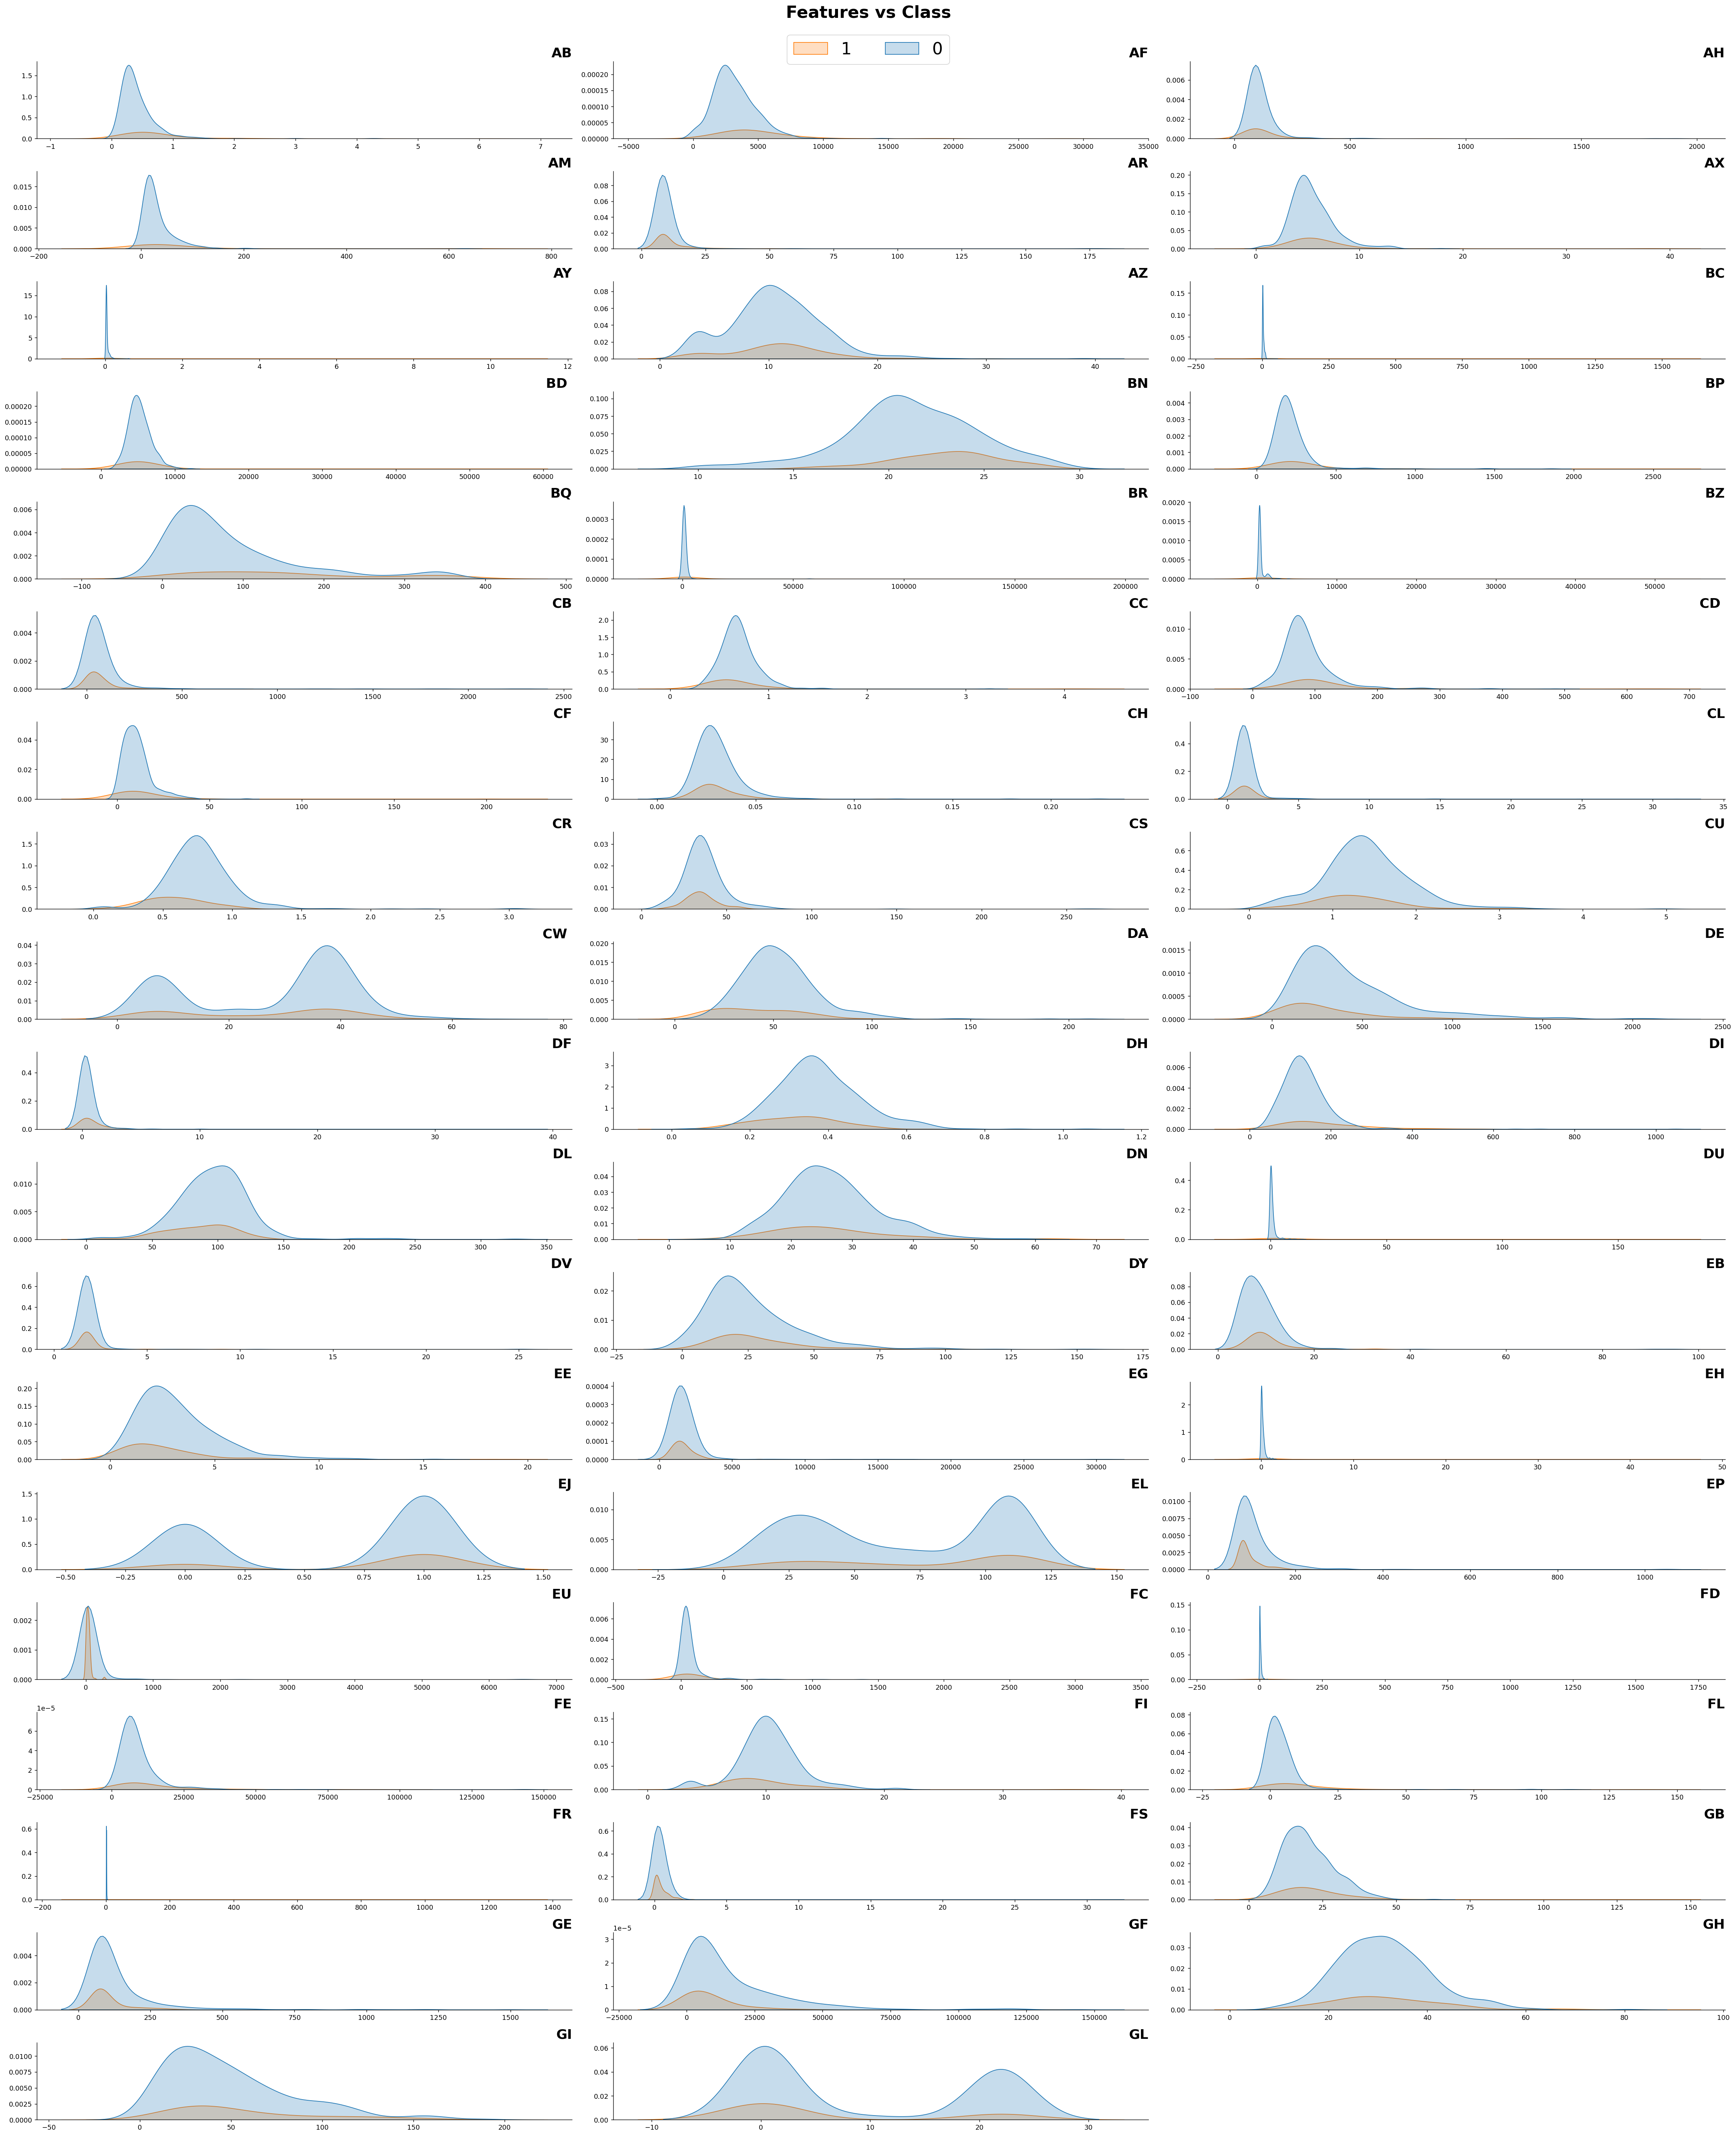

In [19]:
fig = plt.figure(figsize=(6*6, 45), dpi=130)
for idx, col in enumerate(features):
    ax = plt.subplot(19, 3, idx + 1)
    sns.kdeplot(
        data=df, hue='Class', fill=True,
        x=col,legend=False
    )
            
    ax.set_ylabel(''); ax.spines['top'].set_visible(False), 
    ax.set_xlabel(''); ax.spines['right'].set_visible(False)
    ax.set_title(f'{col}', loc='right', 
                 weight='bold', fontsize=20)

fig.suptitle(f'Features vs Class\n\n\n', ha='center',  fontweight='bold', fontsize=25)
fig.legend([1, 0], loc='upper center', bbox_to_anchor=(0.5, 0.97), fontsize=25, ncol=3)
plt.tight_layout()
plt.show()

## **Feature Engineering**

In [20]:
#soon

## **Modeling**

In [21]:
df.columns

Index(['Id', 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class', 'Alpha',
       'Beta', 'Gamma', 'Delta', 'Epsilon'],
      dtype='object')

In [22]:
features = [ 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL'
        ]

target = 'Class'

In [23]:
%%capture

xgb_params = {
    'colsample_bytree': 0.5, 
    'gamma': 1.0,
    'learning_rate': 0.01777187034634523,
    'max_depth': 6,
    'min_child_weight': 1,
    'n_estimators': 1500, 
    'subsample': 0.7629766636827013,
    'verbosity': 0,
    'random_state': 42,
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor'
}

xgb_params1 = {
    'colsample_bytree': 0.5,
    'gamma': 0.08898545568136436,
    'learning_rate': 0.009253274006068297,
    'max_depth': 3,
    'min_child_weight': 1,
    'n_estimators': 1500,
    'subsample': 0.8971494956585011,
    'verbosity': 0,
    'random_state': 42,
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor'
}

lgb_params = {
    'colsample_bytree': 0.5, 
    'learning_rate': 0.02, 
    'max_depth': 8, 
    'min_child_samples': 57,
    'n_estimators': 2445, 
    'num_leaves': 57,
    'reg_alpha': 0.6197994214239195, 
    'reg_lambda': 0.8675671389814725, 
    'subsample': 0.5264255077986388,
    'device': 'gpu',
    'random_state': 42,
    'verbose': -1 
}

lgb1_params = {
    'colsample_bytree': 0.5, 
    'learning_rate': 0.02,
    'max_depth': 4,
    'min_child_samples': 5,
    'n_estimators': 3000,
    'num_leaves': 100,
    'reg_alpha': 1.0,
    'reg_lambda': 1.0,
    'subsample': 0.5,
    'device': 'gpu',
    'random_state': 42,
    'verbose': -1 
} 

lgb2_params = {
    'colsample_bytree': 0.5,
    'learning_rate': 0.02,
    'max_depth': 4,
    'min_child_samples': 5,
    'n_estimators': 1476,
    'num_leaves': 100,
    'reg_alpha':  0.6362952390423132,
    'reg_lambda': 1.0, 
    'subsample': 1.0,
    'device': 'gpu',
    'random_state': 42,
    'verbose': -1 
} 


models = [
    ('xgb', xgb.XGBClassifier(**xgb_params)),
    ('xgb1', xgb.XGBClassifier(**xgb_params1)),
    ('lgb', lgb.LGBMClassifier(**lgb_params)),
    ('lgb1', lgb.LGBMClassifier(**lgb1_params)),
    ('lgb2', lgb.LGBMClassifier(**lgb2_params))
]

stacking_model = StackingClassifier(
        estimators=models[1:],
        final_estimator=xgb.XGBClassifier(**xgb_params),
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
)

voting_model = VotingClassifier(models, voting='soft')

models_iter = {
    'stacking': stacking_model,
    'voting': voting_model
}

# Load your dataset
X = df[features]
y = df[target]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = []
m = []

for train_idx, val_idx in skf.split(X, y):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]

    for model in models_iter.values():
        
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('model', model)
        ])
        pipeline.fit(X_train, y_train)
        val_preds = pipeline.predict_proba(X_valid)
        val_score = balanced_log_loss(y_valid, val_preds[:, 1])
        m.append(pipeline)
        scores.append(val_score)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [24]:
print('*' * 45)
print(f'Log-loss scores: {scores}')
print('*' * 45)
print(f'Log-loss scores mean: {np.mean(scores)}')

*********************************************
Log-loss scores: [0.17727625236517489, 0.2148946464508979, 0.14925085138805735, 0.14499185020757402, 0.23820133240005284, 0.32081789702651947, 0.16192890298938037, 0.15866661163953058, 0.14664147010326975, 0.1442842514708857, 0.21170458623690727, 0.23921483968834809, 0.40063248409353713, 0.45981717587454757, 0.24872013260914502, 0.2035913785717602, 0.3793654376513269, 0.26492652503458913, 0.10728105304583013, 0.11078845310460986]
*********************************************
Log-loss scores mean: 0.22414980659759723


## **Submission**

In [25]:
sample_submission.head()

,Id,class_0,class_1
0,00eed32682bb,0.5,0.5
1,010ebe33f668,0.5,0.5
2,02fa521e1838,0.5,0.5
3,040e15f562a2,0.5,0.5
4,046e85c7cc7f,0.5,0.5


In [26]:
prediction = [0,0]
for model in m:
    prediction += model.predict_proba(test[features])

In [27]:
# sample_submission[['class_0', 'class_1', 'class_2', 'class_3']] = prediction/len(m)
# sample_submission['class_1'] = sample_submission['class_1'] + sample_submission['class_2'] + sample_submission['class_3']
# sample_submission = sample_submission.drop(['class_2', 'class_3'], axis=1)

In [28]:
sample_submission[['class_0', 'class_1']] = prediction/len(m)

In [29]:
sample_submission.head()

,Id,class_0,class_1
0,00eed32682bb,0.867975,0.132025
1,010ebe33f668,0.867975,0.132025
2,02fa521e1838,0.867975,0.132025
3,040e15f562a2,0.867975,0.132025
4,046e85c7cc7f,0.867975,0.132025


In [30]:
sample_submission.to_csv('submission.csv', index=False)